## Technical Indicators
I will also use following technical indicators which I feel help as a feature for prediction of Gold price

1. MACD : The moving average convergence-divergence (MACD) is one of the most powerful and well-known indicators in technical analysis. The indicator is comprised of two exponential moving averages that help measure momentum in a security. The MACD is simply the difference between these two moving averages plotted against a centerline, where the centerline is the point at which the two moving averages are equal.

2. RSI : The relative strength index (RSI) is another well known momentum indicators that’s widely used in technical analysis. The indicator is commonly used to identify overbought and oversold conditions in a security with a range between 0 (oversold) and 100 (overbought).

3. Simple Moving Average (SMA) : simply takes the sum of all of the past closing prices over a time period and divides the result by the total number of prices used in the calculation. For example, a 10-day simple moving average takes the last ten closing prices and divides them by ten.

4. Upper Band

5. Lower Band

6. DIFF

7. Open-Close

8. High-Low

以上是参考项目的原文.  
SMA 简单平均线,用于参考一段时间内的平均价格,因为我们认为短期价格有一些随机性,将SMA引入,平滑价格,不知道是否能改善预测准确性.  
MACD与RSI都是股价预测中的 **趋势投资** 与 **技术分析** 的指标.我认为股票的走势具有反身性,当大家都认为技术分析有用,并以此操作的时候,集体的行为就会真实的影响股价.  


但是两者都是基于股价计算的,可能存在高度相关,因此可能会有 **共线性** 的可能.  
在测试中,我们一个个加入,最后比对效果.

In [12]:
def calculate_SMA(df, peroids):
    SMA = df.rolling(window=peroids, min_periods=peroids, center=False).mean()
    return SMA


MACD比较的是 **短期价格水平** 与 **长期价格水平** 的偏离,比较的是趋势  
RSI比较的是 **近期价格上升与下降** 的力量相对对比,比较的是动量

In [4]:
def calculate_MACD(df, nslow=26, nfast=12):
    emaslow = df.ewm(span=nslow, min_periods=nslow, adjust=True, ignore_na=False).mean()
    emafast = df.ewm(span=nfast, min_periods=nfast, adjust=True, ignore_na=False).mean()
    dif = emafast - emaslow
    Dea = dif.ewm(span=9, min_periods=9, adjust=True, ignore_na=False).mean()
    Histo = dif - Dea
    return dif, Histo

In [245]:
def calculate_wilder_RSI(df, periods=14):
    # wilder's RSI
    delta = df.diff()
    up, down = delta.copy(), delta.copy()

    up[up < 0] = 0
    down[down > 0] = 0

    rUp = up.ewm(span=periods,adjust=False).mean()
    rDown = down.ewm(span=periods, adjust=False).mean().abs()

    rsi = 100 - 100 / (1 + rUp / rDown)
    return rsi

In [251]:
def calculate_normal_RSI(df, periods=14):
    # normal RSI
    delta = df.diff()
    up, down = delta.copy(), delta.copy()

    up[up < 0] = 0
    down[down > 0] = 0

    rUp = up.rolling(window=periods).mean()
    rDown = down.rolling(window=periods).mean().abs()

    rsi = 100 - 100 / (1 + rUp / rDown)
    return rsi

In [5]:
from utils.common import *

In [6]:
data_set = pd.read_pickle('./src/pickle/Dataset.pkl')

In [8]:
display(data_set.X)

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


In [9]:
X = data_set.X
Y = data_set.Y

In [10]:
display(Y)

2012-05-09     4.28
2012-05-10     4.26
2012-05-11     4.20
2012-05-14     4.15
2012-05-15     4.14
              ...  
2026-07-17    28.36
2026-07-20    29.35
2026-07-21    30.21
2026-07-22    32.20
2026-07-23    33.06
Name: Zijin, Length: 3837, dtype: float64

在中国主流的交易软件(同花顺中),日线的SMA一般是5,10,20,30.我们这里各自尝试一下.

In [84]:
sma_5 = calculate_SMA(Y,5)
display(sma_5)

2012-06-19       NaN
2012-06-20       NaN
2012-06-21       NaN
2012-06-24       NaN
2012-06-25     3.946
               ...  
2026-07-16    28.572
2026-07-19    28.970
2026-07-20    29.200
2026-07-21    29.874
2026-07-22    30.636
Name: Zijin, Length: 3807, dtype: float64

In [16]:
sma_10 = calculate_SMA(Y,10)
sma_20 = calculate_SMA(Y,20)
sma_30 = calculate_SMA(Y,30)

In [17]:
X['sma_5'] = sma_5
X['sma_10'] = sma_10
X['sma_20'] = sma_20
X['sma_30'] = sma_30


In [19]:
X = X.dropna(how='any', axis=0)
display(X)

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,sma_5,sma_10,sma_20,sma_30
2012-06-19,965.620268,81.370003,3.4093,1.64,95.14,3.4380,1017.882915,4.076,4.096,4.1030,4.123000
2012-06-20,963.681772,81.489998,3.4101,1.65,93.50,3.3930,1013.239693,4.070,4.083,4.1020,4.115667
2012-06-21,949.587838,82.320000,3.4001,1.63,89.22,3.3035,981.677887,4.054,4.068,4.0990,4.106667
2012-06-22,930.626794,82.220001,3.3677,1.69,89.22,3.3125,996.109712,4.016,4.050,4.0910,4.096333
2012-06-25,930.626794,82.459999,3.3677,1.63,88.69,3.3230,996.109712,3.978,4.028,4.0785,4.087667
...,...,...,...,...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587,28.572,28.146,27.4240,28.042667
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719,28.970,28.253,27.3695,28.086000
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967,29.200,28.512,27.4925,28.144000
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122,29.874,28.996,27.7200,28.294000


对SMA应该进行标准化,否则其数值与当前股价是高度相关.  
此外,在02中,我们是用当天的因子来拟合当天的预测值.实际上我们应该用前一天的数据来预测今天的股价.尤其是SMA与当日股价高度相关.

比如说,我们要用19号的数据预测20号的股价.因此,我们在验证集Y中,应该吧20号的数据变成19号,这样就实现了当天已知的信息来预测明天.

In [20]:
display(Y)

2012-05-09     4.28
2012-05-10     4.26
2012-05-11     4.20
2012-05-14     4.15
2012-05-15     4.14
              ...  
2026-07-17    28.36
2026-07-20    29.35
2026-07-21    30.21
2026-07-22    32.20
2026-07-23    33.06
Name: Zijin, Length: 3837, dtype: float64

In [21]:
Y.index = Y.index - pd.Timedelta(days=1)

In [22]:
display(Y)

2012-05-08     4.28
2012-05-09     4.26
2012-05-10     4.20
2012-05-13     4.15
2012-05-14     4.14
              ...  
2026-07-16    28.36
2026-07-19    29.35
2026-07-20    30.21
2026-07-21    32.20
2026-07-22    33.06
Name: Zijin, Length: 3837, dtype: float64

In [23]:
Y = Y[Y.index >= '2012-06-19']
display(Y)

2012-06-19     4.06
2012-06-20     3.99
2012-06-21     3.89
2012-06-24     3.89
2012-06-25     3.90
              ...  
2026-07-16    28.36
2026-07-19    29.35
2026-07-20    30.21
2026-07-21    32.20
2026-07-22    33.06
Name: Zijin, Length: 3807, dtype: float64

由于前移了一天,因此Y少了一天.应该把X最后一行删去.

In [34]:
X = X[:-1]

由03_02可知,模型的问题不在于选用,而是因子构建的不完全.在这里,我们还是采用Lasso模型进行训练.

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV
from sklearn.preprocessing import StandardScaler

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
from sklearn.linear_model import Lasso

In [36]:
X_train = X[:-500]
X_test = X[-500:]
Y_train = Y[:-500]
Y_test = Y[-500:]

RMSE： 0.9991454030750965
R²： 0.9845139805879642


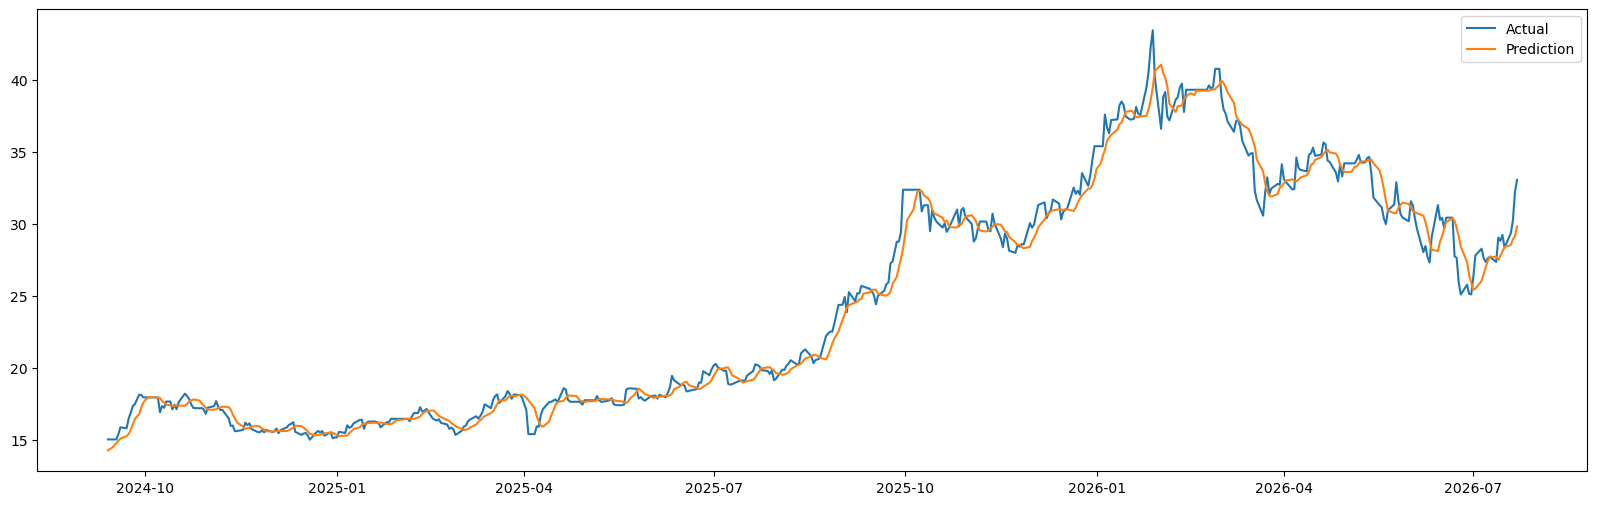

A_500                   0.010028
Dollar Index            0.000000
cn_10y_rate            -0.000000
us_10y_rate             0.000000
brent                  -0.000000
Copper Futures Price    0.000000
Gold Futures Price      0.033165
sma_5                   4.011683
sma_10                  0.000000
sma_20                  0.000000
sma_30                  0.000000
dtype: float64

In [53]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-5, 1, 1000)
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid_lasso.fit(X_train, Y_train)

Y_pred = grid_lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("RMSE：", rmse)
print("R²：", r2)
plt.figure(figsize=(20,6))
plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, Y_pred, label='Prediction')
plt.legend()
plt.show()    
coef = grid_lasso.best_estimator_.named_steps["lasso"].coef_
display(pd.Series(coef, index=X_train.columns))

sma5,10,20,30实际上是高度共线性的.如果我们只选用其中一项,那么计算结果会更好吗?

In [162]:
def Lasso_test(x_train,y_train,x_test,y_test,Max_iter=10000):
    pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=Max_iter))
    ])

    ts_split = TimeSeriesSplit(n_splits=5)

    parameters = {
    'lasso__alpha': np.logspace(-5, 1, 1000)
}

    grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

    grid_lasso.fit(x_train, y_train)

    Y_pred = grid_lasso.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, Y_pred))
    r2 = r2_score(y_test, Y_pred)

    print("RMSE：", rmse)
    print("R²：", r2)
    plt.figure(figsize=(20,6))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, Y_pred, label='Prediction')
    plt.legend()
    plt.show()

    coef = grid_lasso.best_estimator_.named_steps["lasso"].coef_
    display(pd.Series(coef, index=x_train.columns))

In [180]:
X_train_sma5 = X_train.drop(columns=['sma_10', 'sma_20', 'sma_30'])
X_train_sma10 = X_train.drop(columns=['sma_5', 'sma_20', 'sma_30'])
X_train_sma20 = X_train.drop(columns=['sma_5', 'sma_10', 'sma_30'])
X_train_sma30 = X_train.drop(columns=['sma_5', 'sma_10', 'sma_20'])

In [46]:
X_test_sma5 = X_test.drop(columns=['sma_10', 'sma_20', 'sma_30'])
X_test_sma10 = X_test.drop(columns=['sma_5', 'sma_20', 'sma_30'])
X_test_sma20 = X_test.drop(columns=['sma_5', 'sma_10', 'sma_30'])
X_test_sma30 = X_test.drop(columns=['sma_5', 'sma_10', 'sma_20'])

In [183]:
common_time = X_train_sma5.index.intersection(Y_train.index)
X_train_sma5 = X_train_sma5.loc[common_time]
Y_train = Y_train.loc[common_time]

RMSE： 1.001280190169801
R²： 0.9844477346305468


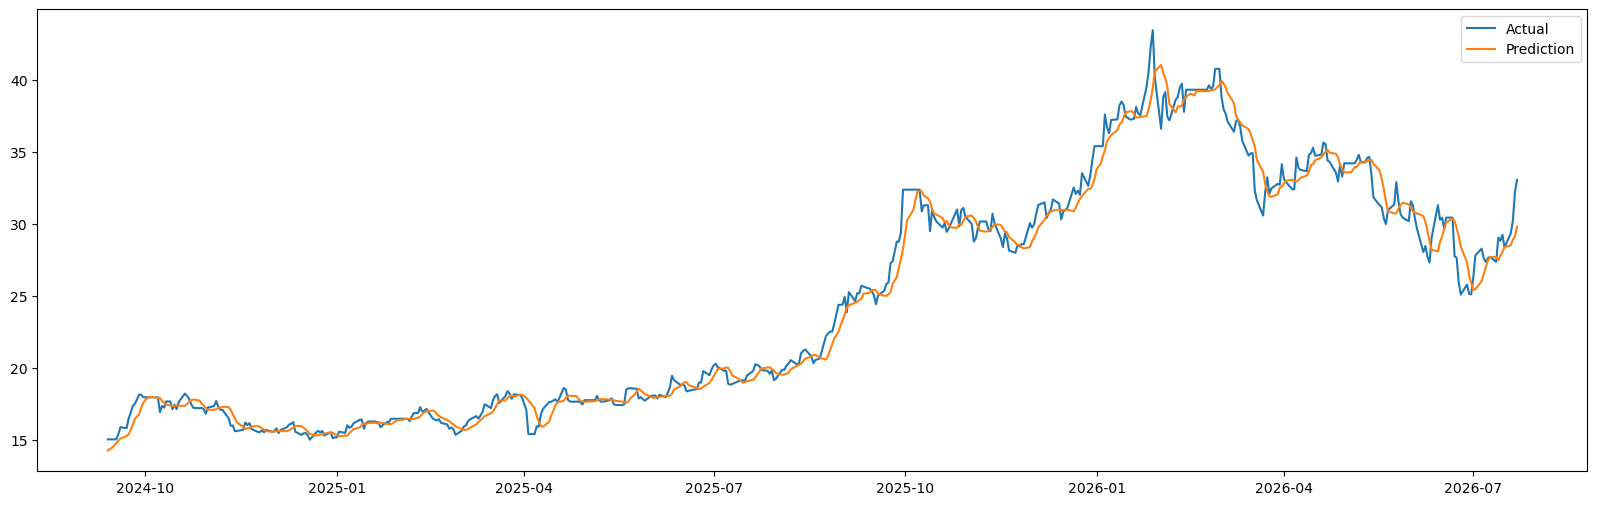

A_500                   0.006197
Dollar Index            0.000000
cn_10y_rate            -0.000000
us_10y_rate             0.000000
brent                  -0.000000
Copper Futures Price    0.000000
Gold Futures Price      0.030606
sma_5                   4.015621
dtype: float64

In [168]:
Lasso_test(X_train_sma5,Y_train,X_test_sma5,Y_test)

RMSE： 1.2829226337368536
R²： 0.9744680876716484


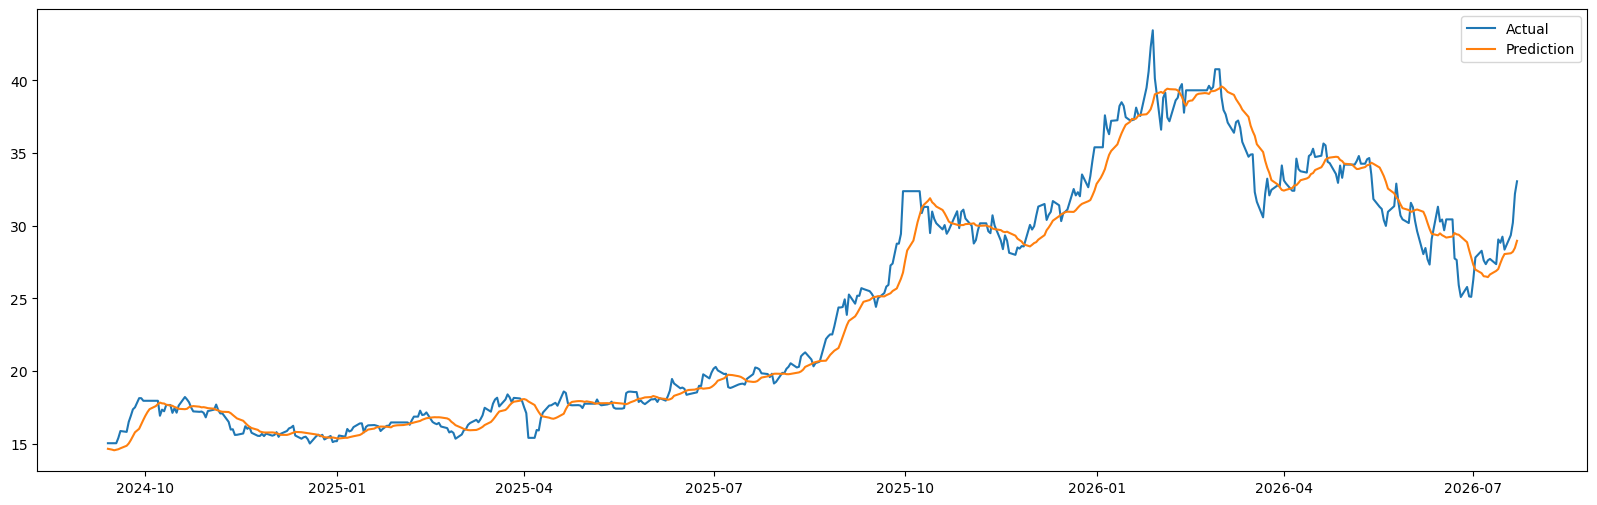

In [48]:
Lasso_test(X_train_sma10,Y_train,X_test_sma10,Y_test)

RMSE： 1.6697582519998901
R²： 0.956749651920584


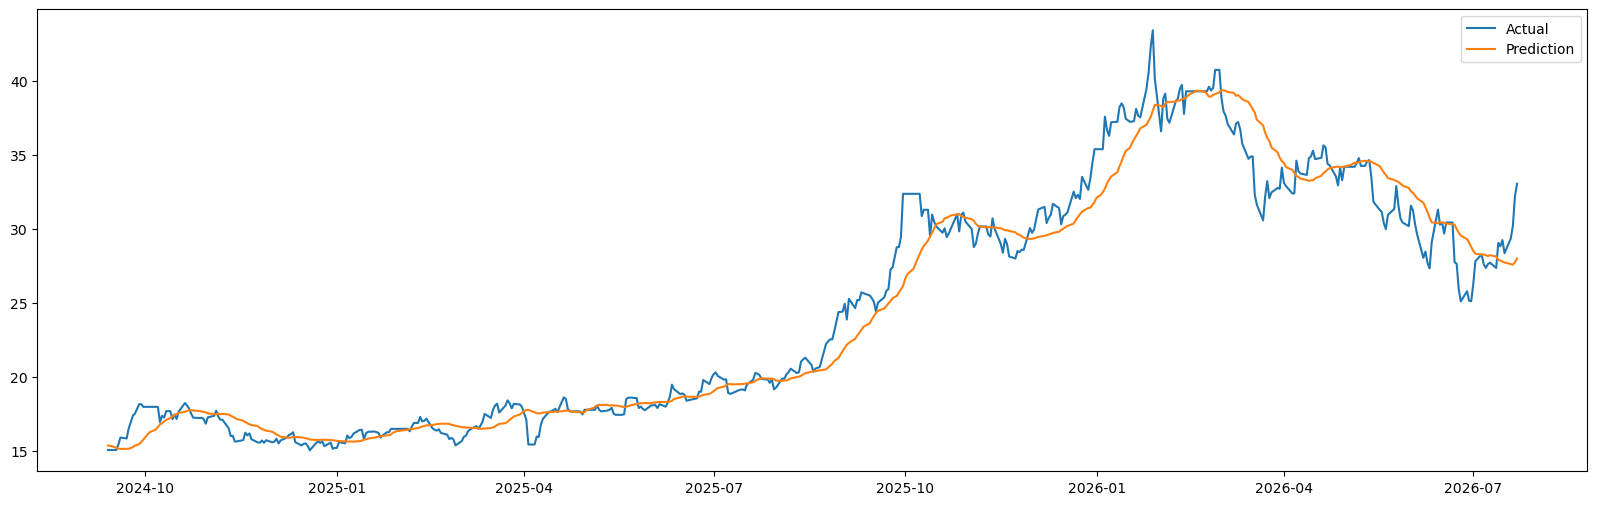

In [49]:
Lasso_test(X_train_sma20,Y_train,X_test_sma20,Y_test)

RMSE： 1.9897162588989525
R²： 0.9385863785485179


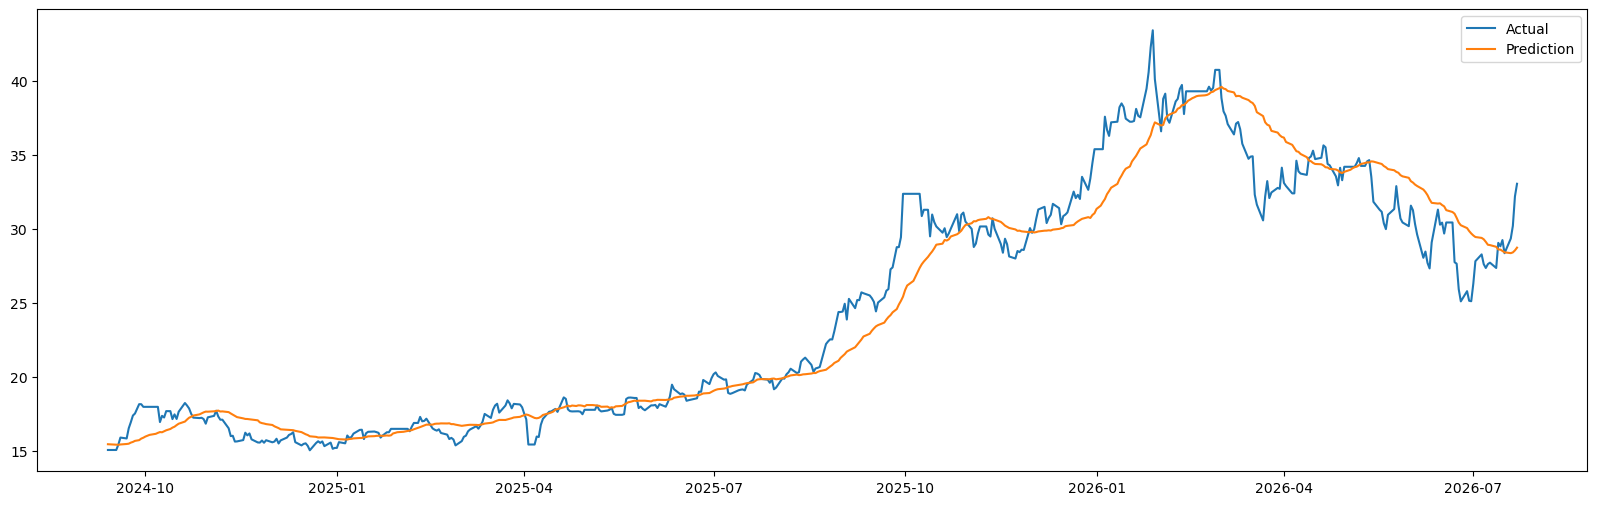

In [50]:
Lasso_test(X_train_sma30,Y_train,X_test_sma30,Y_test)

由于SMA_5与股票价格高度相关,即股票的价格每日的变动可能不大,用昨天来预测今天的价格,两者基本持平.这样的话,就把其它的因子系数都压成了0.因为价格本身就与这些因子高度相关.

即股票价格的 **持续性** 导致了相对好的 **准确率** ,并非是模型本身预测能力优秀.

这样的话,我们应该放弃R^2,转而看只用SMA_5来预测明日股价的RMSE,本身有多少.

In [152]:
sma_5_train = sma_5[4:-500]
sma_5_test = sma_5[-500:]

In [153]:
Y_train = Y[:-500]
Y_test = Y[-500:]

In [154]:
sma_5_train = pd.DataFrame(sma_5_train)
sma_5_test = pd.DataFrame(sma_5_test)

In [155]:
common_time = sma_5_train.index.intersection(Y_train.index)
sma_5_train = sma_5_train.loc[common_time]
Y_train = Y_train.loc[common_time]

In [156]:
sma_5_train

,Zijin
2012-06-25,3.946
2012-06-26,3.908
2012-06-27,3.876
2012-06-28,3.874
2012-07-01,3.876
...,...
2024-09-08,14.752
2024-09-09,14.498
2024-09-10,14.402
2024-09-11,14.306


In [157]:
Y_train

2012-06-25     3.90
2012-06-26     3.87
2012-06-27     3.83
2012-06-28     3.88
2012-07-01     3.90
              ...  
2024-09-08    14.15
2024-09-09    14.22
2024-09-10    14.20
2024-09-11    14.20
2024-09-12    14.68
Name: Zijin, Length: 3303, dtype: float64

In [158]:
common_time = sma_5_test.index.intersection(Y_test.index)
sma_5_test = sma_5_test.loc[common_time]
Y_test = Y_test.loc[common_time]

In [159]:
display(sma_5_train)

,Zijin
2012-06-25,3.946
2012-06-26,3.908
2012-06-27,3.876
2012-06-28,3.874
2012-07-01,3.876
...,...
2024-09-08,14.752
2024-09-09,14.498
2024-09-10,14.402
2024-09-11,14.306


In [160]:
display(sma_5_test)

,Zijin
2024-09-13,14.468
2024-09-15,14.632
2024-09-16,14.800
2024-09-17,14.968
2024-09-18,15.112
...,...
2026-07-16,28.572
2026-07-19,28.970
2026-07-20,29.200
2026-07-21,29.874


RMSE： 0.74469740526118
R²： 0.9913971551334283


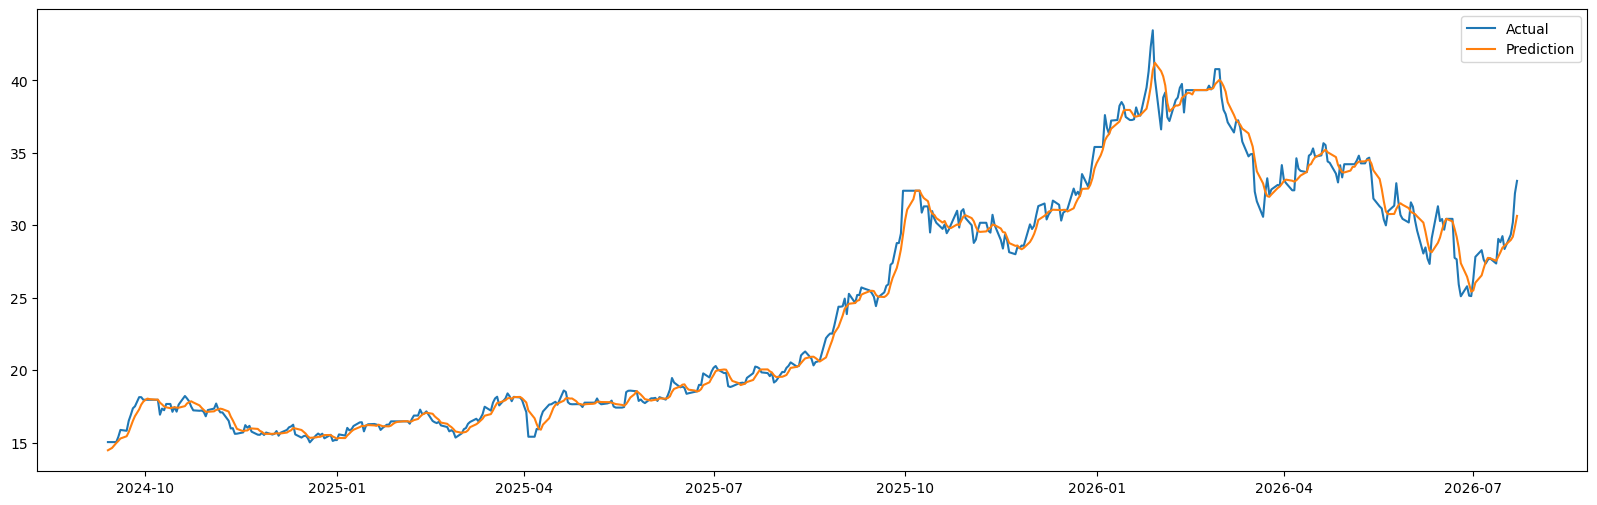

Zijin    4.072358
dtype: float64

In [163]:
Lasso_test(sma_5_train,Y_train,sma_5_test,Y_test)

如果只用SMA来预测股票价格,反而效果更好,R^2更大,RMSE更小,在长时间来看,五日日线就拟合程度而言,反而更好.  
真的是这样吗?我们把预测集再缩小一下.

RMSE： 0.9110206178131603
R²： 0.9783299636642107


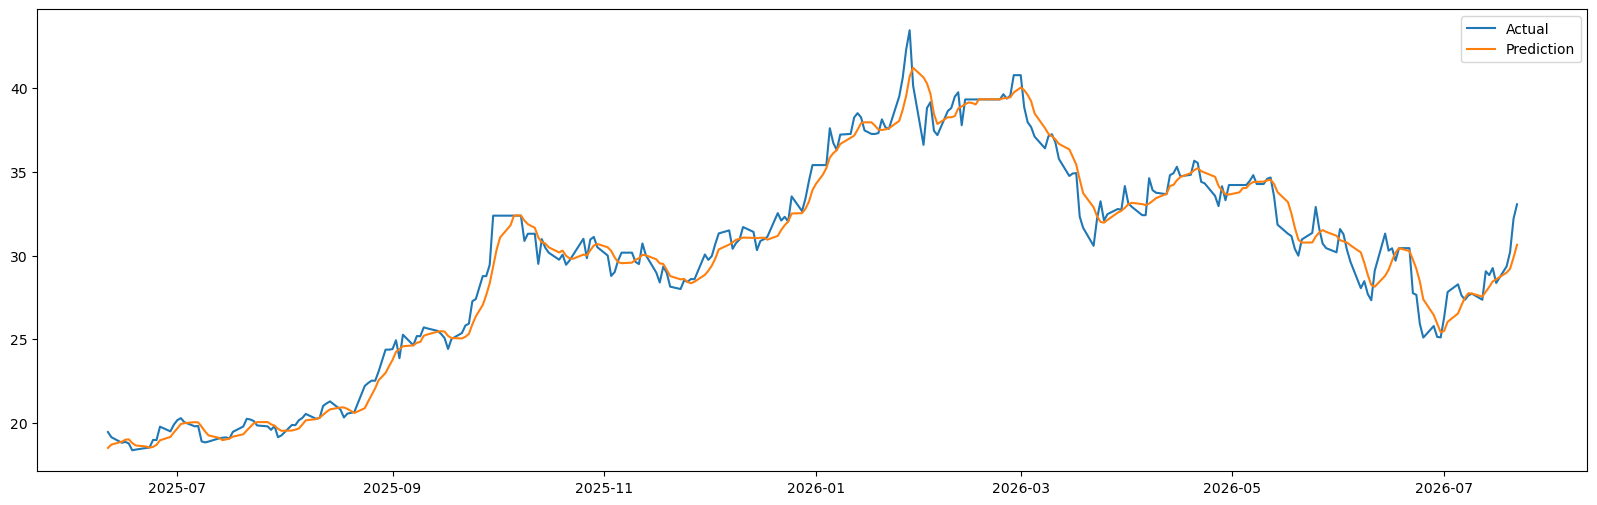

Zijin    4.072358
dtype: float64

In [170]:
sma_5_train = sma_5[4:-500]
sma_5_test = sma_5[300:]
Y_train = Y[:-500]
Y_test = Y[-300:]

common_time = sma_5_train.index.intersection(Y_train.index)
sma_5_train = sma_5_train.loc[common_time]
Y_train = Y_train.loc[common_time]

common_time = sma_5_test.index.intersection(Y_test.index)
sma_5_test = sma_5_test.loc[common_time]
Y_test = Y_test.loc[common_time]

sma_5_train = pd.DataFrame(sma_5_train)
sma_5_test = pd.DataFrame(sma_5_test)
Lasso_test(sma_5_train,Y_train,sma_5_test,Y_test)


In [184]:
X_train_sma5 = X_train.drop(columns=['sma_10', 'sma_20', 'sma_30'])
X_test_sma5 = X_test.drop(columns=['sma_10', 'sma_20', 'sma_30'])

RMSE： 1.1849665385096706
R²： 0.9639707099642046


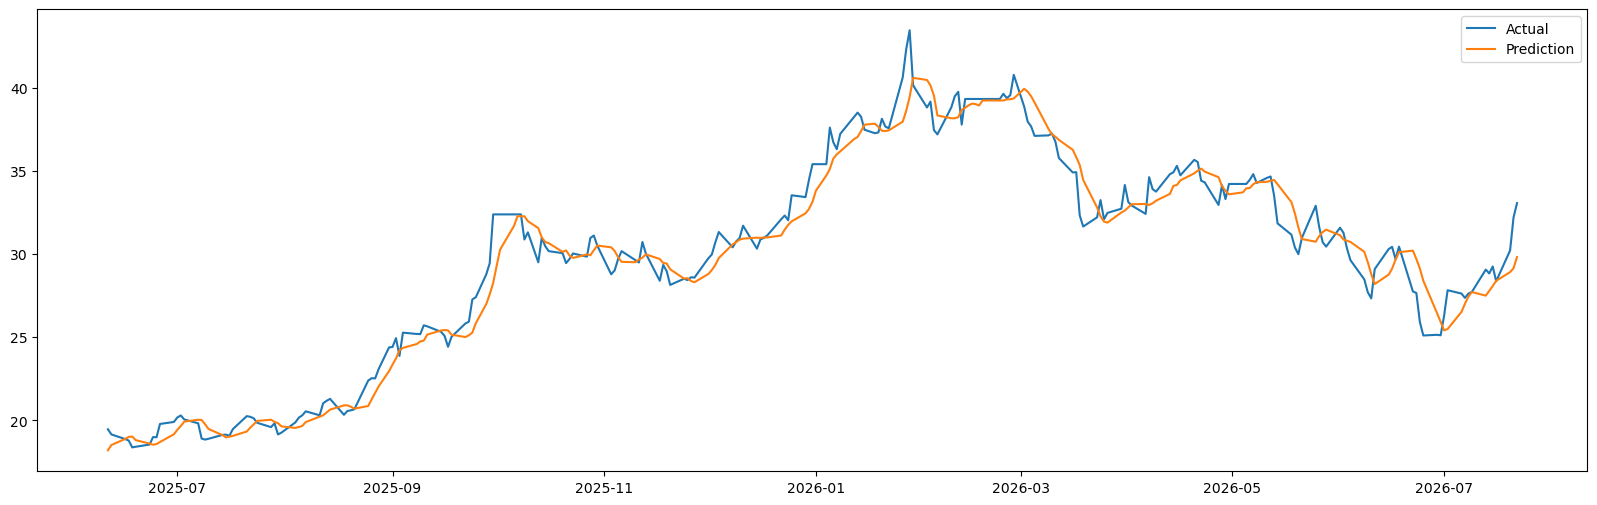

A_500                   0.006609
Dollar Index            0.000000
cn_10y_rate            -0.000000
us_10y_rate             0.000000
brent                  -0.000000
Copper Futures Price    0.000000
Gold Futures Price      0.030720
sma_5                   4.013994
dtype: float64

In [186]:
Y_train = Y[:-500]
Y_test = Y[-300:]

X_train_sma5.dropna(inplace=True)


common_time = X_train_sma5.index.intersection(Y_train.index)
X_train_sma5 = X_train_sma5.loc[common_time]
Y_train = Y_train.loc[common_time]

common_time = X_test_sma5.index.intersection(Y_test.index)
X_test_sma5 = X_test_sma5.loc[common_time]
Y_test = Y_test.loc[common_time]

X_train_sma5 = pd.DataFrame(X_train_sma5)
X_test_sma5 = pd.DataFrame(X_test_sma5)
Lasso_test(X_train_sma5,Y_train,X_test_sma5,Y_test)


还是同样的结果.加入了其他解释的因子,数据准确率反而下降了.  
就股票而言,P(t+1)≈P(t)≈SMA5  
市场价格可能已经吸收了上述的因子,A_500与Gold Future还有一点系数,证明近年来股价主要看金和市场整体情绪对价格有较小的影响.

---

下面,我们加入MACD,看看MACD是否会对模型产生较好的效果.

In [202]:
X = X.drop(columns=['sma_5','sma_10','sma_20','sma_30'])

In [212]:
dif,macd = calculate_MACD(Y)

In [219]:
dif = dif.rename('dif')
macd = macd.rename('macd')

In [223]:
common_time = macd.index.intersection(X.index)
dif = dif.loc[common_time]
macd = macd.loc[common_time]
X = X.loc[common_time]

In [224]:
dif.shape

(3109,)

In [225]:
macd.shape

(3109,)

In [226]:
X.shape

(3109, 7)

In [227]:
X['dif'] = dif
X['macd'] = macd

In [229]:
X.dropna(inplace=True)

In [230]:
Y.index = Y.index - pd.Timedelta(days=1)

In [231]:
common_time = X.index.intersection(Y.index)
X = X.loc[common_time]
Y = Y.loc[common_time]

In [234]:
X_train = X[:-500]
X_test = X[-500:]
Y_train = Y[:-500]
Y_test = Y[-500:]

RMSE： 4.175447025758698
R²： 0.7478081263699352


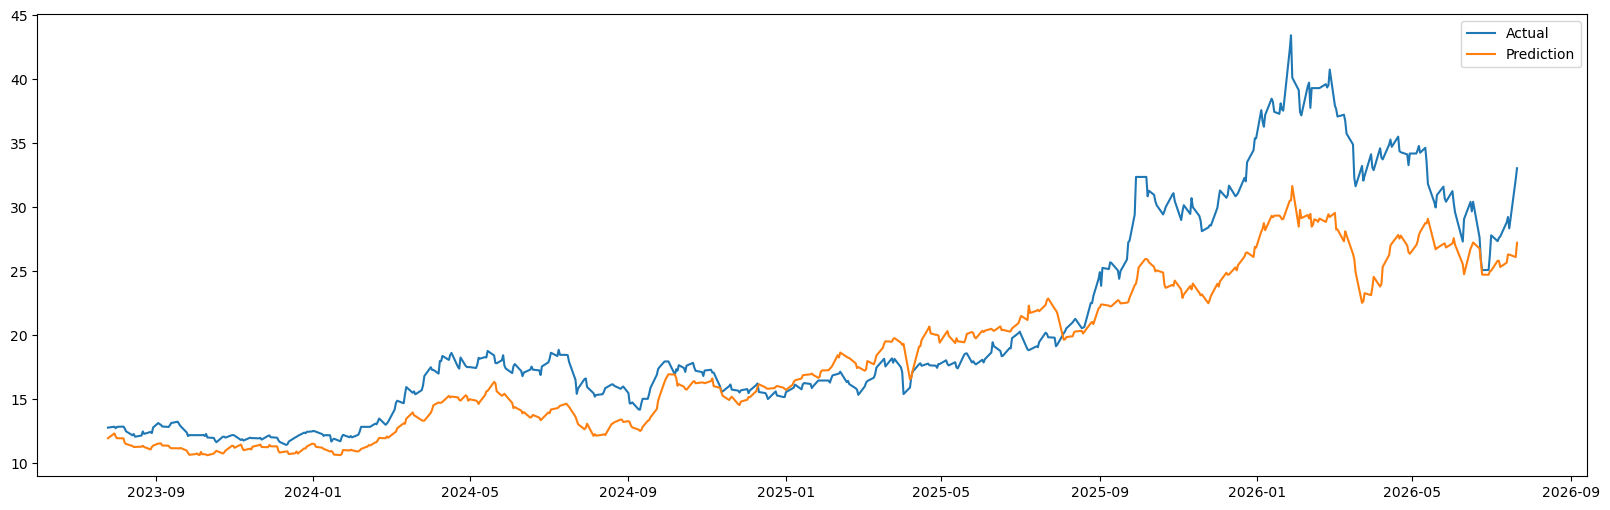

A_500                   1.383446
Dollar Index           -0.541065
cn_10y_rate            -0.876468
us_10y_rate             0.994073
brent                  -0.390559
Copper Futures Price    1.249308
Gold Futures Price      0.797502
dif                     0.186592
macd                    0.007977
dtype: float64

In [235]:
Lasso_test(X_train,Y_train,X_test,Y_test)

相比于没有加入dif,macd,模型的解释能力反而下降了.但有可能与这次训练和测试集有一定关联.我们重新设置一下时间.

In [241]:
#此为之前模型的测试集开始时间
X_train = X[X.index <'2024-9-10']
Y_train = Y[Y.index<'2024-9-10']
X_test = X[X.index >= '2024-9-10']
Y_test = Y[Y.index >= '2024-9-10']

RMSE： 3.6242510833329242
R²： 0.8042293112835162


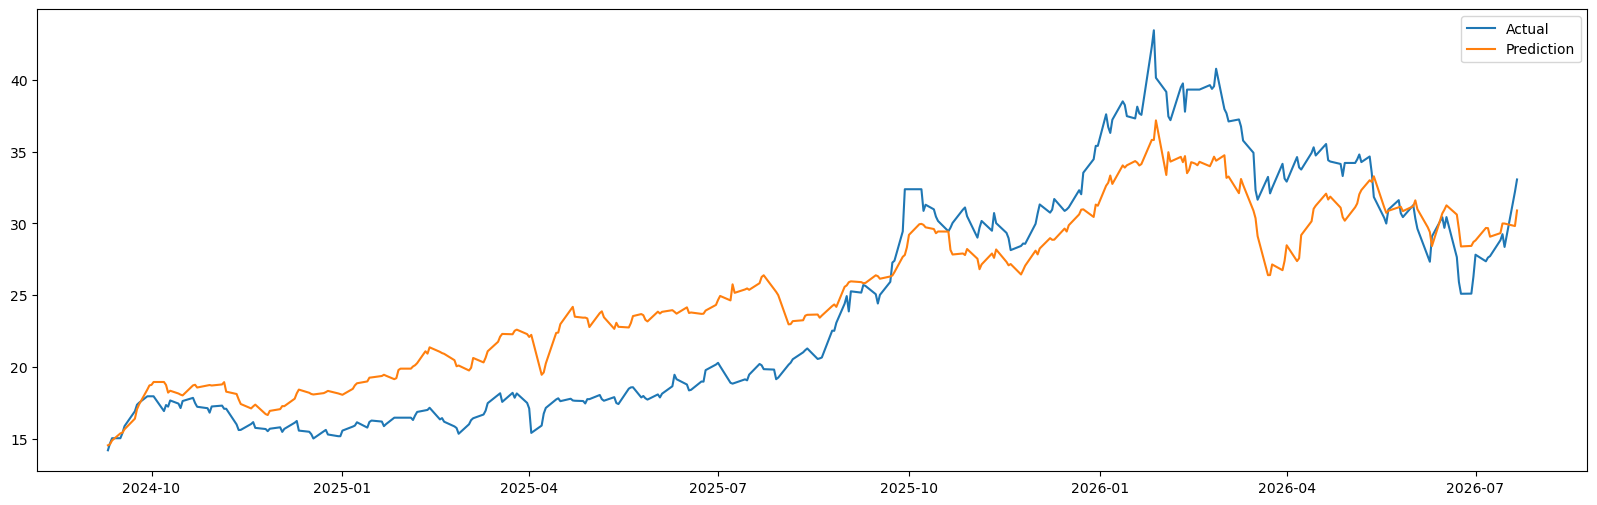

A_500                   1.147671
Dollar Index           -0.760005
cn_10y_rate            -1.097714
us_10y_rate             1.644780
brent                  -0.673299
Copper Futures Price    1.331941
Gold Futures Price      1.329141
dif                     0.239414
macd                   -0.007744
dtype: float64

In [242]:
Lasso_test(X_train,Y_train,X_test,Y_test)

有一定的改善  
rmse:3.6790->3.6242  
R^2:0.7900->0.8042  
我们认为可以保留这个数据.


---

这回,再加上RSI

In [278]:
X = data_set.X

In [280]:
X = X.drop(columns=['sma_5','sma_10','sma_20','sma_30'])

In [281]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


In [283]:
Y

2012-05-07     4.28
2012-05-08     4.26
2012-05-09     4.20
2012-05-12     4.15
2012-05-13     4.14
              ...  
2026-07-15    28.36
2026-07-18    29.35
2026-07-19    30.21
2026-07-20    32.20
2026-07-21    33.06
Name: Zijin, Length: 3837, dtype: float64

In [284]:
normal_rsi = calculate_normal_RSI(Y)
wilder_rsi = calculate_wilder_RSI(Y)

In [290]:
normal_rsi

2012-05-27    34.782609
2012-05-28    34.042553
2012-05-29    43.181818
2012-05-30    48.717949
2012-06-02    51.282051
                ...    
2026-07-15    64.719359
2026-07-18    73.208379
2026-07-19    75.757576
2026-07-20    77.570093
2026-07-21    76.095618
Name: Zijin, Length: 3811, dtype: float64

In [291]:
wilder_rsi

2012-05-08     0.000000
2012-05-09     0.000000
2012-05-12     0.000000
2012-05-13     0.000000
2012-05-14     0.000000
                ...    
2026-07-15    53.260820
2026-07-18    61.955004
2026-07-19    67.933715
2026-07-20    77.411393
2026-07-21    80.312928
Name: Zijin, Length: 3836, dtype: float64

In [293]:
normal_rsi.dropna(inplace=True)
wilder_rsi.dropna(inplace=True)
common_time = normal_rsi.index.intersection(wilder_rsi.index).intersection(X.index)

In [295]:
normal_rsi = normal_rsi.loc[common_time]
wilder_rsi = wilder_rsi.loc[common_time]
X = X.loc[common_time]

In [296]:
X_normal = X.copy()
X_normal['norm_rsi'] = normal_rsi
X_wilder = X.copy()
X_wilder['wilder_rsi'] = wilder_rsi

In [297]:
Y = Y.loc[common_time]

In [303]:
X_train = X_normal[X_normal.index < '2024-09-10']
X_test = X_normal[X_normal.index >= '2024-09-10']
Y_train = Y.loc[X_train.index]
Y_test = Y.loc[X_test.index]

In [300]:
X_train 

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,norm_rsi
2012-05-28,994.944520,82.440002,3.3418,1.74,107.55,3.4620,971.701087,34.042553
2012-05-29,994.944520,82.440002,3.3718,1.74,107.55,3.4620,971.701087,43.181818
2012-05-30,992.791885,83.010002,3.3766,1.63,103.85,3.3945,980.987684,48.717949
2012-06-04,962.076460,82.550003,3.3469,1.53,97.74,3.3135,1011.608208,57.142857
2012-06-05,962.960960,82.800003,3.3568,1.57,98.65,3.2950,1013.490620,52.173913
...,...,...,...,...,...,...,...,...
2024-09-01,1379.436838,101.830002,2.1457,3.84,77.82,4.2188,1562.339197,48.017621
2024-09-02,1379.436838,101.830002,2.1457,3.84,77.82,4.1837,1562.339197,28.673835
2024-09-03,1379.436838,101.830002,2.1432,3.84,76.46,4.0715,1562.339197,18.442623
2024-09-04,1370.971840,101.360001,2.1336,3.77,74.67,4.0580,1564.535345,22.553191


In [304]:
Y_train

2012-05-28     4.11
2012-05-29     4.14
2012-05-30     4.14
2012-06-04     4.19
2012-06-05     4.14
              ...  
2024-09-01    15.49
2024-09-02    14.68
2024-09-03    14.68
2024-09-04    14.76
2024-09-09    14.20
Name: Zijin, Length: 2145, dtype: float64

In [301]:
X_test

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,norm_rsi
2024-09-10,1346.862401,101.629997,2.1143,3.65,70.34,4.0765,1576.394632,12.359551
2024-09-11,1346.239585,101.680000,2.1044,3.65,70.31,4.1200,1576.269169,26.910299
2024-09-12,1339.861892,101.370003,2.0998,3.68,73.81,4.1720,1600.803181,37.500000
2024-09-14,1337.464631,100.760002,2.0425,3.63,73.96,4.2505,1613.038859,35.215947
2024-09-16,1337.464631,100.760002,2.0403,3.63,73.96,4.2505,1613.038859,38.823529
...,...,...,...,...,...,...,...,...
2026-07-13,2123.896462,101.279999,1.7442,4.62,81.62,6.2810,2508.000328,66.293393
2026-07-14,2172.004277,100.940002,1.7402,4.58,83.69,6.3780,2548.221260,74.325909
2026-07-15,2157.308216,100.500000,1.7406,4.55,83.08,6.3410,2537.491450,64.719359
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719,77.570093


RMSE： 3.7638319290978406
R²： 0.7902844697418836


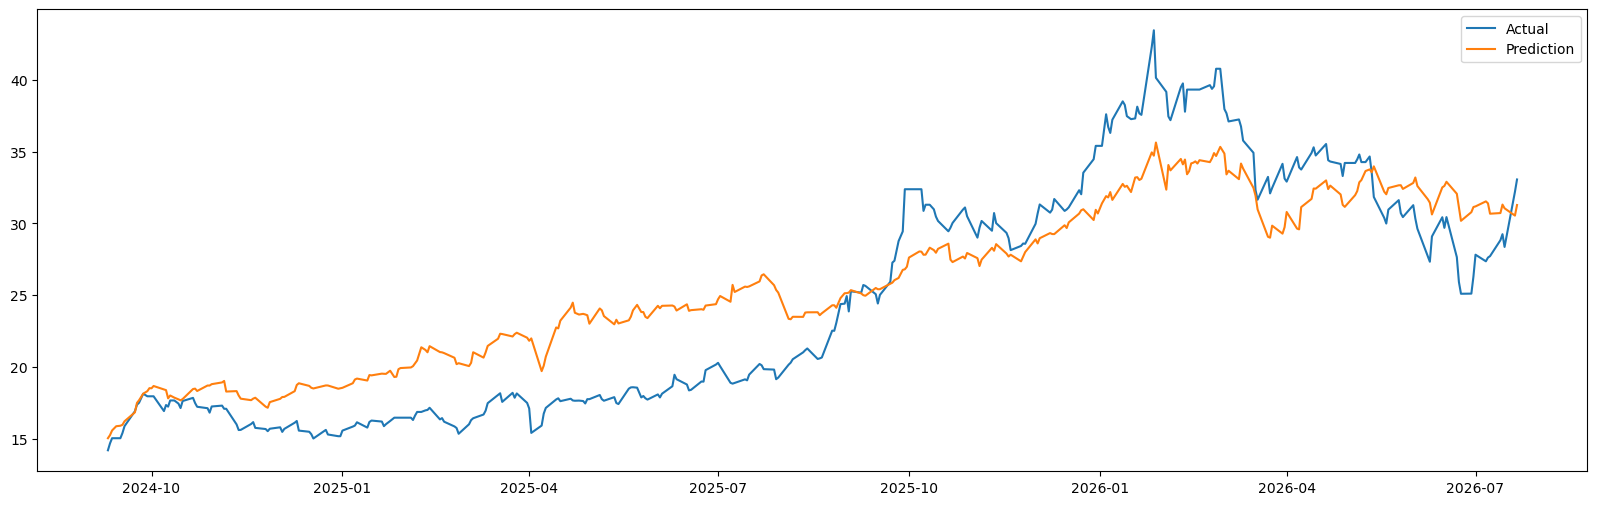

A_500                   1.223413
Dollar Index           -0.872826
cn_10y_rate            -1.101939
us_10y_rate             1.712711
brent                  -0.702983
Copper Futures Price    1.296881
Gold Futures Price      1.396581
norm_rsi                0.151353
dtype: float64

In [305]:
Lasso_test(X_train,Y_train,X_test,Y_test)

没有太大的效果,虽然给予了RSI系数,但是对于预测准确性来说没有提高.

In [306]:
X_train = X_wilder[X_wilder.index < '2024-09-10']
X_test = X_wilder[X_wilder.index >= '2024-09-10']
Y_train = Y.loc[X_train.index]
Y_test = Y.loc[X_test.index]

RMSE： 3.757821560448244
R²： 0.7909537138885733


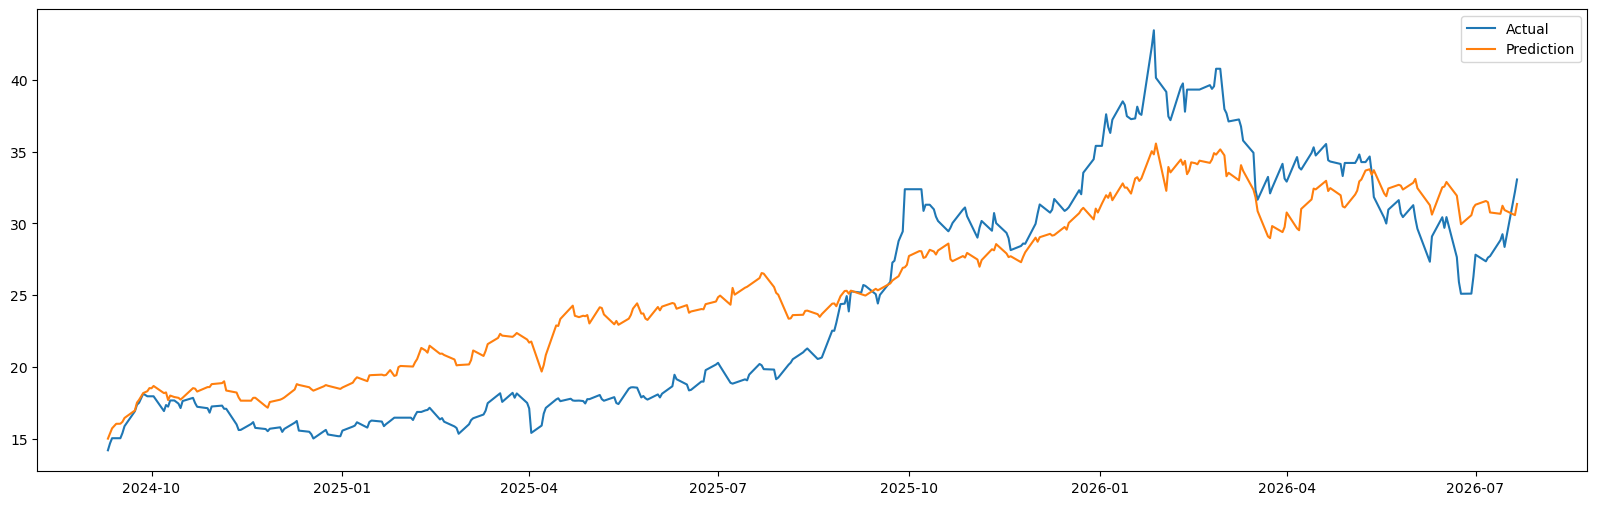

A_500                   1.223301
Dollar Index           -0.879363
cn_10y_rate            -1.113925
us_10y_rate             1.713085
brent                  -0.693102
Copper Futures Price    1.291760
Gold Futures Price      1.389584
wilder_rsi              0.187172
dtype: float64

In [307]:
Lasso_test(X_train,Y_train,X_test,Y_test)

Wilder比Normal RSI略好一点.但是加入了以后,RMSE从3.679->3.757,而R^2几乎没有下降.

---

综上,我们应该放弃RSI,短期的股价涨幅相对变化,对于模型预测而言没有什么效果.  
在macd与diff中,我们看到系数,diff为0.23,macd为-0.0077,macd可能没有太大效果.我们将其删去,看看是否会对结果造成影响,dif本身也可以代表近来股价变化的趋势.

In [308]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-28,994.944520,82.440002,3.3418,1.74,107.55,3.4620,971.701087
2012-05-29,994.944520,82.440002,3.3718,1.74,107.55,3.4620,971.701087
2012-05-30,992.791885,83.010002,3.3766,1.63,103.85,3.3945,980.987684
2012-06-04,962.076460,82.550003,3.3469,1.53,97.74,3.3135,1011.608208
2012-06-05,962.960960,82.800003,3.3568,1.57,98.65,3.2950,1013.490620
...,...,...,...,...,...,...,...
2026-07-13,2123.896462,101.279999,1.7442,4.62,81.62,6.2810,2508.000328
2026-07-14,2172.004277,100.940002,1.7402,4.58,83.69,6.3780,2548.221260
2026-07-15,2157.308216,100.500000,1.7406,4.55,83.08,6.3410,2537.491450
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719


In [309]:
Y

2012-05-28     4.11
2012-05-29     4.14
2012-05-30     4.14
2012-06-04     4.19
2012-06-05     4.14
              ...  
2026-07-13    28.83
2026-07-14    29.25
2026-07-15    28.36
2026-07-20    32.20
2026-07-21    33.06
Name: Zijin, Length: 2469, dtype: float64

In [310]:
X['dif'] = dif
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,dif
2012-05-28,994.944520,82.440002,3.3418,1.74,107.55,3.4620,971.701087,NaN
2012-05-29,994.944520,82.440002,3.3718,1.74,107.55,3.4620,971.701087,NaN
2012-05-30,992.791885,83.010002,3.3766,1.63,103.85,3.3945,980.987684,NaN
2012-06-04,962.076460,82.550003,3.3469,1.53,97.74,3.3135,1011.608208,NaN
2012-06-05,962.960960,82.800003,3.3568,1.57,98.65,3.2950,1013.490620,NaN
...,...,...,...,...,...,...,...,...
2026-07-13,2123.896462,101.279999,1.7442,4.62,81.62,6.2810,2508.000328,-0.524001
2026-07-14,2172.004277,100.940002,1.7402,4.58,83.69,6.3780,2548.221260,-0.393037
2026-07-15,2157.308216,100.500000,1.7406,4.55,83.08,6.3410,2537.491450,-0.252446
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719,0.063135


In [311]:
X.dropna(inplace=True)
common_time = X.index.intersection(Y.index)
X = X.loc[common_time]
Y = Y.loc[common_time]

In [312]:
X_train = X[X.index <'2024-9-10']
Y_train = Y[Y.index<'2024-9-10']
X_test = X[X.index >= '2024-9-10']
Y_test = Y[Y.index >= '2024-9-10']

RMSE： 3.625504673823194
R²： 0.8040938578000438


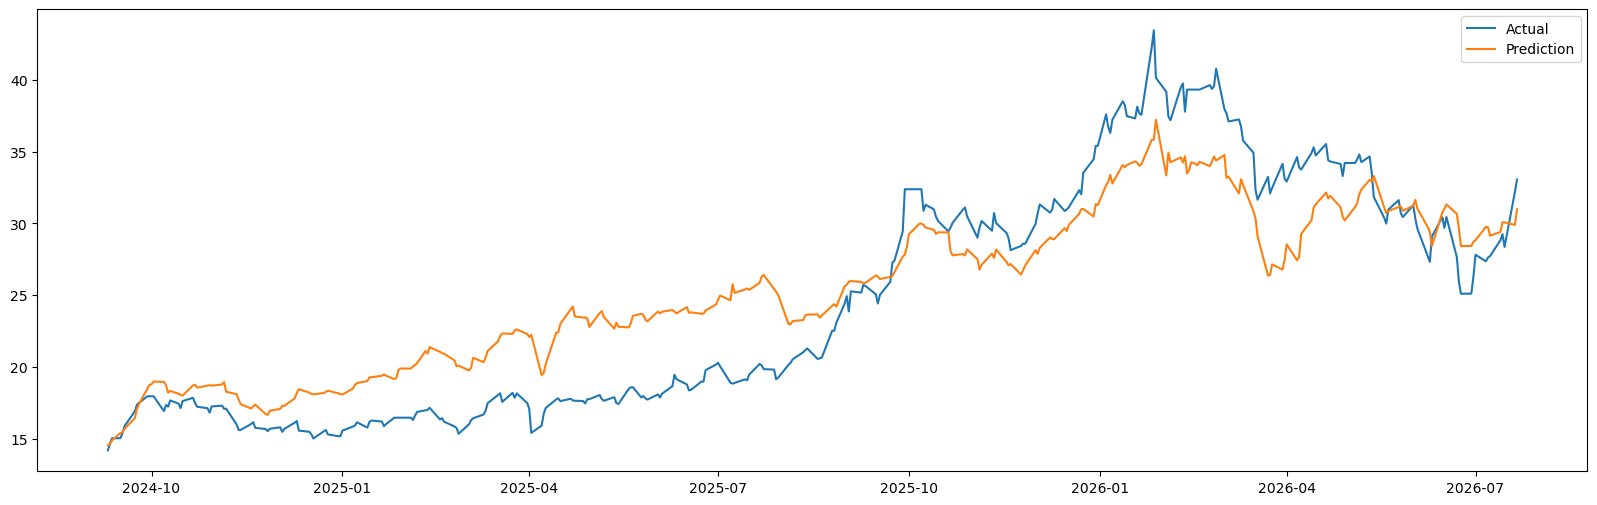

A_500                   1.142897
Dollar Index           -0.759796
cn_10y_rate            -1.095079
us_10y_rate             1.645368
brent                  -0.677738
Copper Futures Price    1.335606
Gold Futures Price      1.330681
dif                     0.234936
dtype: float64

In [313]:
Lasso_test(X_train,Y_train,X_test,Y_test)

RMSE:3.6242->3.6255  
R^2:80.42%->80.41%  
两者相差不大,但是保留下来也没什么坏处.  

相比于原始的模型.  
RMSE:3.679->3.625,  
R^2:79%->80.41%  
预测效果略有提升,但是仍然不明显,无法解释巨大的波动.

而RSI加入后,并没有太好的效果.我认为MACD已经蕴含了今日的股价,因此能略微提升一点预测的准确性.但是RSI实际上是超买超卖的一个指标,用它应该来预测股价的涨幅,而并不是用它0-100的数字来预测股价的绝对值.

至于SMA5,约等于用昨天等于今天来拟合,两者高度相关,不应该直接作为一个因子.相当于用股价来预测股价,本质是线性外推,没有意义.我们应该找出基本面和宏观因素来找出价值,而非价格.